<a href="https://colab.research.google.com/github/KowshiqKatta/Generative-AI/blob/main/LangGraph/Iterative_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langgraph langchain_openai
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Literal, Annotated

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 4.0 MB/s eta 0:00:00


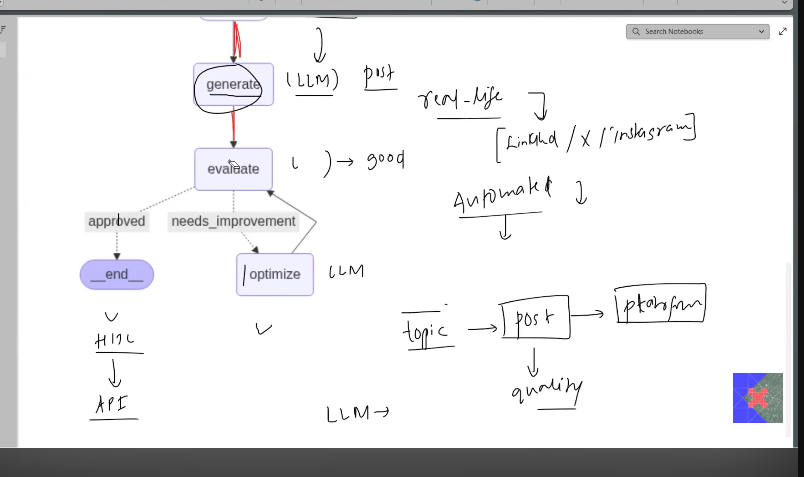

In [39]:
import operator

In [31]:
import os
os.environ["OPENAI_API_KEY"] = "YOUR API KEY" # Replace with your actual API key
generator_llm = ChatOpenAI(model = 'gpt-4o-mini')
evaluator_llm = ChatOpenAI(model = 'gpt-4o-mini')
optimizer_llm = ChatOpenAI(model = 'gpt-4o-mini')

In [32]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [33]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [40]:
class TweetState(TypedDict):

  topic: str
  tweet: str
  evaluation: Literal["approved", "needs_improvement"]
  feedback: str
  iteration: int
  max_iteration: int

  tweet_history: Annotated[list[str], operator.add]
  feedback_history: Annotated[list[str], operator.add]

In [41]:
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content
    return {
        'tweet': response,
        'tweet_history': [response]
            }

def evaluate_tweet(state: TweetState):

  # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]
    response = structured_evaluator_llm.invoke(messages)
    return {
        'evaluation': response.evaluation,
        'feedback': response.feedback,
        'feedback_history': [response.feedback]
    }

def optimize_tweet(state: TweetState):

  messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]


  response = optimizer_llm.invoke(messages).content
  iteration = state['iteration'] + 1

  return {
      'tweet': response,
      'iteration': iteration,
      'tweet_history': [response]
  }

def route_evaluation(state: TweetState):

  if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
    return 'approved'
  else:
    return 'needs_improvement'

In [42]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation,
                            {
                                'approved': END,
                                'needs_improvement': 'optimize'
                            })
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

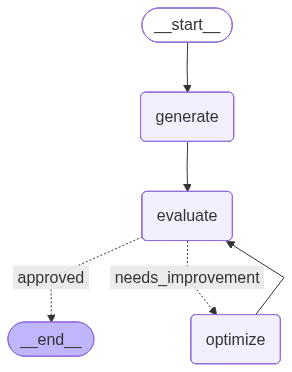

In [43]:
workflow

In [44]:
initial_state = {
    'topic': "Indian Railways",
    'iteration': 1,
    'max_iteration': 5
}

workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': 'Indian Railways: where time is just a suggestion, the chai is hot but your patience is lukewarm, and "2 minutes late" means you might as well schedule your full vacation around the wait. If you can’t find your seat, just borrow someone else\'s—they did the same! 🚂☕️ #TrainChronicles',
 'evaluation': 'approved',
 'feedback': "This tweet showcases a strong sense of originality, encapsulating the unique experience of traveling with Indian Railways in a humorous yet relatable way. The humor level is enjoyable, giving a playful touch on time management and chai culture. The punchiness could be tweaked a bit since it's a bit lengthy; however, it effectively employs relatable scenarios that enhance its virality potential. The format adheres to the guidelines, keeping it under 280 characters without falling into a traditional setup-punchline structure. Overall, it's a compelling tweet with a good chance to resonate widely.",
 'iteration': 1,
 'max_iterat